In [1]:
from ucimlrepo import fetch_ucirepo

steel_plates_faults = fetch_ucirepo(id=198)

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

X = steel_plates_faults.data.features
y = steel_plates_faults.data.targets

y = np.argmax(y.values, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).long().to(device)
y_test_tensor = torch.from_numpy(y_test).long().to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


class SteelFaultNetDynamic(nn.Module):
    def __init__(self, activation_fn):
        super(SteelFaultNetDynamic, self).__init__()
        self.fc1 = nn.Linear(27, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 7)
        self.activation_fn = activation_fn

    def forward(self, x):
        x = self.activation_fn(self.fc1(x))
        x = self.activation_fn(self.fc2(x))
        x = self.fc3(x)
        return x

# ==================== KONFIGURACJA EKSPERYMENTU ====================
best_lr = 0.001 # Wartość ustalona w Exp 1
activations = {
    "ReLU": F.relu,
    "Tanh": torch.tanh,
    "Sigmoid": torch.sigmoid
}
num_repeats = 5
epochs = 20
act_results = {}

for name, fn in activations.items():
    print(f"\n>>> Testowanie funkcji aktywacji: {name}")
    run_accuracies = []
    
    for i in range(num_repeats):
        model = SteelFaultNetDynamic(activation_fn=fn).to(device)
        optimizer = optim.Adam(model.parameters(), lr=best_lr)
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(x_batch), y_batch)
                loss.backward()
                optimizer.step()
        
        model.eval()
        with torch.no_grad():
            outputs = model(X_test_tensor)
            _, predicted = torch.max(outputs, 1)
            acc = (predicted == y_test_tensor).float().mean().item() * 100
            run_accuracies.append(acc)
            print(f"   Próba {i+1}: {acc:.2f}%")
    
    act_results[name] = run_accuracies


>>> Testowanie funkcji aktywacji: ReLU
   Próba 1: 76.09%
   Próba 2: 75.06%
   Próba 3: 75.58%
   Próba 4: 74.55%
   Próba 5: 75.58%

>>> Testowanie funkcji aktywacji: Tanh
   Próba 1: 74.55%
   Próba 2: 74.04%
   Próba 3: 74.55%
   Próba 4: 75.06%
   Próba 5: 74.55%

>>> Testowanie funkcji aktywacji: Sigmoid
   Próba 1: 69.41%
   Próba 2: 68.64%
   Próba 3: 70.18%
   Próba 4: 70.69%
   Próba 5: 69.15%


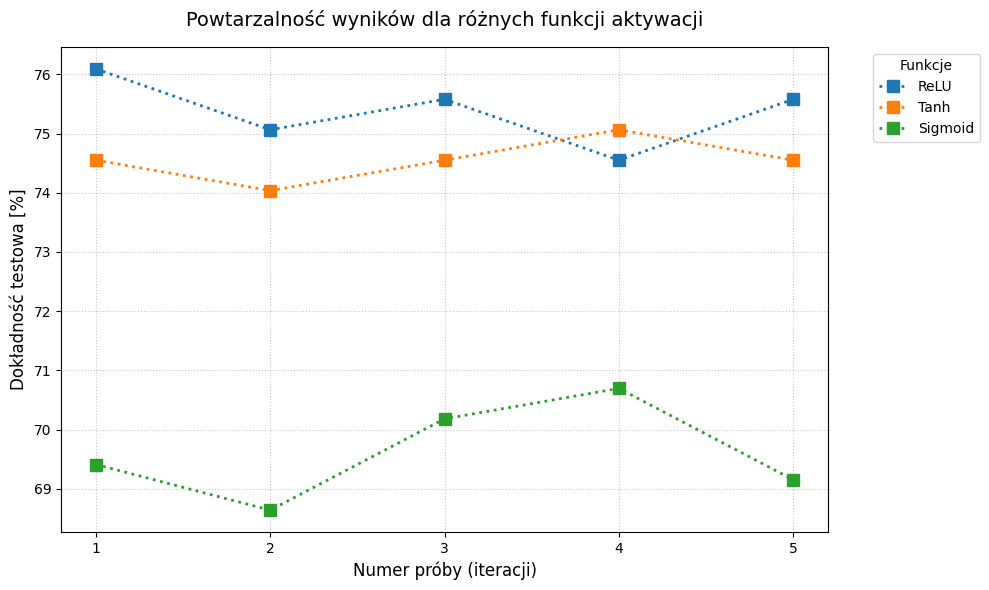

In [2]:
# WYKRES 3: Rozrzut dla funkcji aktywacji
plt.figure(figsize=(10, 6))
for name, accs in act_results.items():
    plt.plot(range(1, num_repeats + 1), accs, marker='s', linestyle=':', linewidth=2, markersize=8, label=name)

plt.title('Powtarzalność wyników dla różnych funkcji aktywacji', fontsize=14, pad=15)
plt.xticks(range(1, num_repeats + 1))
plt.xlabel('Numer próby (iteracji)', fontsize=12)
plt.ylabel('Dokładność testowa [%]', fontsize=12)
plt.legend(title="Funkcje", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

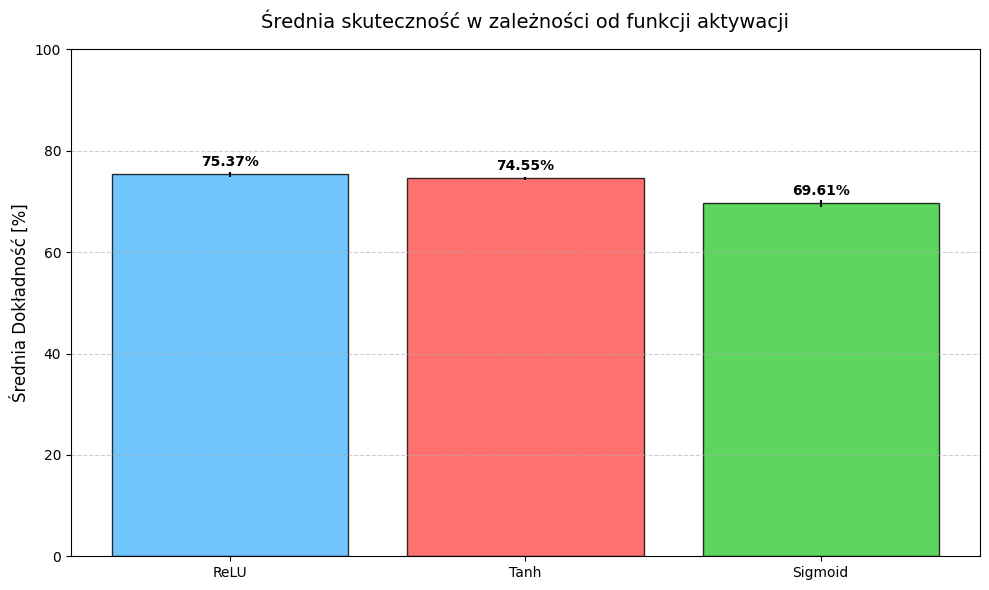

In [5]:
# WYKRES 4: Średnia dla funkcji aktywacji
plt.figure(figsize=(10, 6))
act_means = [np.mean(act_results[name]) for name in activations.keys()]
act_labels = list(activations.keys())
std_dev = [np.std(act_results[name]) for name in activations.keys()]

colors_act = ['#4db8ff', '#ff4d4d', '#33cc33']
bars = plt.bar(act_labels, act_means, color=colors_act, alpha=0.8, edgecolor='black', yerr=std_dev)

plt.title('Średnia skuteczność w zależności od funkcji aktywacji', fontsize=14, pad=15)
plt.ylabel('Średnia Dokładność [%]', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

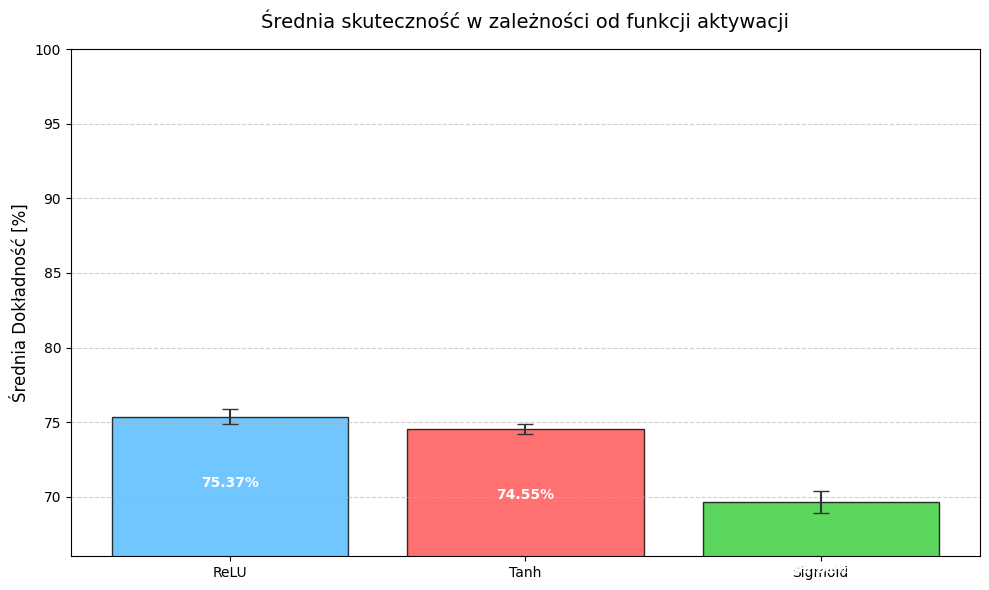

In [9]:
# WYKRES 4: Średnia dla funkcji aktywacji
from math import floor
plt.figure(figsize=(10, 6))

act_labels = list(activations.keys())

# Dobra praktyka: liczymy średnie i SD za jednym zamachem
act_means = [np.mean(act_results[name]) for name in act_labels]
std_dev = [np.std(act_results[name]) for name in act_labels]

colors_act = ['#4db8ff', '#ff4d4d', '#33cc33']

# Dodaliśmy capsize=6 dla ładnych daszków oraz error_kw do stylizacji wąsów błędu
bars = plt.bar(
    act_labels, 
    act_means, 
    yerr=std_dev, 
    color=colors_act, 
    alpha=0.8, 
    edgecolor='black', 
    capsize=6,
    error_kw={'ecolor': '#333333', 'elinewidth': 1.5}
)

plt.title('Średnia skuteczność w zależności od funkcji aktywacji', fontsize=14, pad=15)
plt.ylabel('Średnia Dokładność [%]', fontsize=12)
min_wartosc = min([mean - sd for mean, sd in zip(act_means, std_dev)])
plt.ylim(floor(min_wartosc) - 2, 100) # Podniosłem do 110, żeby ewentualne wąsy błędu powyżej 100% nie zostały ucięte
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Poprawione dodawanie tekstu - teraz wartości są WESZŁE w słupki, tuż pod krawędzią
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval - 4, # 4 punkty poniżej szczytu słupka
        f'{yval:.2f}%', 
        ha='center', 
        va='top', # Wyrównanie od góry tekstu
        fontweight='bold',
        color='white' # Biały tekst zazwyczaj lepiej wygląda na kolorowych słupkach
    )

plt.tight_layout()
plt.show()

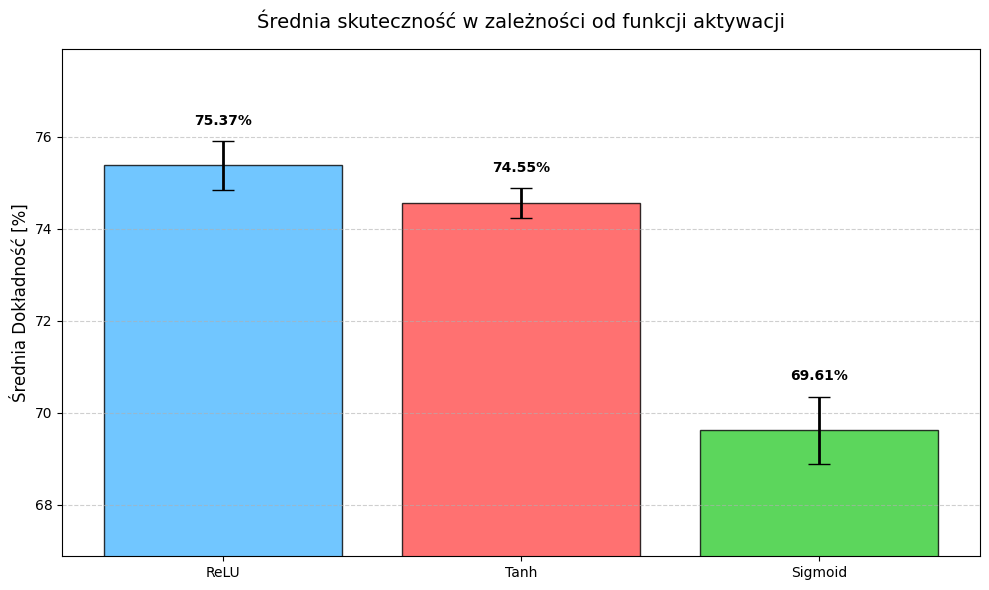

In [10]:
# WYKRES 4: Średnia dla funkcji aktywacji
plt.figure(figsize=(10, 6))

act_labels = list(activations.keys())
act_means = [np.mean(act_results[name]) for name in act_labels]
std_dev = [np.std(act_results[name]) for name in act_labels]

colors_act = ['#4db8ff', '#ff4d4d', '#33cc33']

# Rysujemy słupki
bars = plt.bar(
    act_labels, 
    act_means, 
    yerr=std_dev, 
    color=colors_act, 
    alpha=0.8, 
    edgecolor='black', 
    capsize=8, # Zwiększyłem daszki, żeby były bardziej widoczne
    error_kw={'ecolor': 'black', 'elinewidth': 2} # Grubsza linia wąsów
)

plt.title('Średnia skuteczność w zależności od funkcji aktywacji', fontsize=14, pad=15)
plt.ylabel('Średnia Dokładność [%]', fontsize=12)

# --- TUTAJ JEST MAGIA PRZESKALOWANIA ---
# Szukamy najniższego i najwyższego punktu uwzględniając wąsy błędu
ymin = min([m - s for m, s in zip(act_means, std_dev)]) - 2  # -2 dla zapasu z dołu
ymax = min(max([m + s for m, s in zip(act_means, std_dev)]) + 2, 102) # max do 102%, żeby nie przesadzić

plt.ylim(ymin, ymax) 
# ---------------------------------------

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Dodawanie tekstu nad wąsami błędu
for i, bar in enumerate(bars):
    yval = bar.get_height()
    sd = std_dev[i]
    
    # Pozycja tekstu: wysokość słupka + długość wąsa + mały odstęp
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + sd + 0.3, # 0.3% powyżej górnego wąsa błędu
        f'{yval:.2f}%', 
        ha='center', 
        va='bottom', 
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()